# GAVD: extract features + train kNN classifier

## 1.  Setup

In [1]:
# Configure matplotlib FIRST before any other imports
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

# Verify matplotlib backend
print(f"Matplotlib backend: {matplotlib.get_backend()}")

# Enable interactive mode
plt.ion()

Matplotlib backend: module://matplotlib_inline.backend_inline


In [2]:
# Suppress TensorFlow and MediaPipe logs
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['GLOG_minloglevel'] = '3'

import sys
import string
import contextlib
import pandas as pd
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import defaultdict

# Setup paths
project_root = Path.cwd().parent.parent
video_base_path = project_root / "data" / "youtube"
data_root = project_root / "experiments" / "exp3" / "data"

sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"Data root: {data_root}")
print(f"Video path: {video_base_path}")

Project root: /Users/pmui/dev/alex/alexpose
Data root: /Users/pmui/dev/alex/alexpose/experiments/exp3/data
Video path: /Users/pmui/dev/alex/alexpose/data/youtube


In [3]:
from ambient.gavd import GAVDDataLoader
from ambient.pose.keypoint_extractor import SequenceKeypointExtractor
from ambient.pose.joint_angles import get_joint_angles

from ambient.classification.knn_classifier import (
    KNNGaitClassifier,
    KNNClassifierConfig,
    GaitFeatureVector
)

print("✓ Imports successful")

✓ Imports successful


## 2. Explore Training Dataset

In [4]:
data_root

PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp3/data')

In [5]:
# Get condition directories
condition_paths = [
    p for p in data_root.iterdir() 
    if p.is_dir() and p.name[0] in string.ascii_letters
]

len(condition_paths)

3

In [6]:

print(f"Found {len(condition_paths)} conditions:\n")
for path in sorted(condition_paths):
    csv_files = list(path.glob("*.csv"))
    print(f"  {path.name:15s}: {len(csv_files)} CSV files")

Found 3 conditions:

  normal         : 12 CSV files
  parkinsons     : 9 CSV files
  stroke         : 12 CSV files


## 3.  Extract Keypoints from One Gait (CSV) Sequence

In [7]:
normal_path = condition_paths[2]
stroke_path = condition_paths[0]
parkinsons_path = condition_paths[1]

normal_path, stroke_path, parkinsons_path

(PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp3/data/normal'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp3/data/stroke'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp3/data/parkinsons'))

In [8]:
# Let's get the first CSV from the normal_path
normal_csv = list(normal_path.glob("*.csv"))[7]
stroke_csv = list(stroke_path.glob("*.csv"))[0]
parkinsons_csv = list(parkinsons_path.glob("*.csv"))[3]
normal_csv, stroke_csv, parkinsons_csv

(PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp3/data/normal/cljo30lnz001q3n6lopfty7q5.csv'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp3/data/stroke/cljvvsucg00043n6l4evgn7q4.csv'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp3/data/parkinsons/cljnz5sb1000o3n6lntosswwz.csv'))

In [9]:
gavd_loader = GAVDDataLoader()

normal_df = gavd_loader.load_gavd_data(normal_csv)
stroke_df = gavd_loader.load_gavd_data(stroke_csv)
parkinsons_df = gavd_loader.load_gavd_data(parkinsons_csv)

normal_df.shape, stroke_df.shape, parkinsons_df.shape

((80, 12), (166, 12), (81, 12))

In [10]:
normal_sid = normal_df.iloc[0]["seq"]
stroke_sid = stroke_df.iloc[0]["seq"]
parkinsons_sid = parkinsons_df.iloc[0]["seq"]

normal_sid, stroke_sid, parkinsons_sid

('cljo30lnz001q3n6lopfty7q5',
 'cljvvsucg00043n6l4evgn7q4',
 'cljnz5sb1000o3n6lntosswwz')

In [11]:
video_base_path

PosixPath('/Users/pmui/dev/alex/alexpose/data/youtube')

In [12]:
extractor = SequenceKeypointExtractor()

In [13]:
# Extract with automatic filtering - only frames with visible person
normal_keypoints_array = extractor.extract_from_sequence(
    sequence_data=normal_df,
    video_base_path=video_base_path,
    verbose=True,
    filter_empty=True,      # ← Remove frames with < 25 keypoints
    min_keypoints=25        # ← Require at least 25 out of 33 keypoints
)

stroke_keypoints_array = extractor.extract_from_sequence(
    sequence_data=stroke_df,
    video_base_path=video_base_path,
    verbose=True,
    filter_empty=True,
    min_keypoints=25
)

parkinsons_keypoints_array = extractor.extract_from_sequence(
    sequence_data=parkinsons_df,
    video_base_path=video_base_path,
    verbose=True,
    filter_empty=True,
    min_keypoints=25
)

# Print statistics for each
print("\n" + "="*70)
print("EXTRACTION SUMMARY")
print("="*70)
extractor.print_extraction_statistics(normal_keypoints_array, "Normal Gait")
extractor.print_extraction_statistics(stroke_keypoints_array, "Stroke Gait")
extractor.print_extraction_statistics(parkinsons_keypoints_array, "Parkinsons Gait")

I0000 00:00:1768975174.652772 11489276 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Max
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1768975174.702846 11489279 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768975174.712627 11489279 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
2026-01-20 21:59:34.713 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:416 - Processing sequence: cljo30lnz001q3n6lopfty7q5 (80 frames)


	frame 311 (1/80)


W0000 00:00:1768975175.343287 11489278 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


	frame 321 (11/80)
	frame 331 (21/80)
	frame 341 (31/80)
	frame 351 (41/80)
	frame 361 (51/80)
	frame 371 (61/80)
	frame 381 (71/80)


2026-01-20 21:59:49.908 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:441 - Processed 80/80 frames successfully
2026-01-20 21:59:49.909 | INFO     | ambient.pose.keypoint_extractor:_filter_keypoints:514 - Filtered to 64/80 frames (min 25 keypoints, removed 16)
2026-01-20 21:59:49.910 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:416 - Processing sequence: cljvvsucg00043n6l4evgn7q4 (166 frames)


	frame 1 (1/166)
	frame 11 (11/166)
	frame 21 (21/166)
	frame 31 (31/166)
	frame 41 (41/166)
	frame 51 (51/166)
	frame 61 (61/166)
	frame 71 (71/166)
	frame 81 (81/166)
	frame 91 (91/166)
	frame 101 (101/166)
	frame 111 (111/166)
	frame 121 (121/166)
	frame 131 (131/166)
	frame 141 (141/166)
	frame 151 (151/166)
	frame 161 (161/166)


2026-01-20 22:00:19.593 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:441 - Processed 166/166 frames successfully
2026-01-20 22:00:19.593 | INFO     | ambient.pose.keypoint_extractor:_filter_keypoints:514 - Filtered to 166/166 frames (min 25 keypoints, removed 0)
2026-01-20 22:00:19.594 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:416 - Processing sequence: cljnz5sb1000o3n6lntosswwz (81 frames)


	frame 1482 (1/81)
	frame 1492 (11/81)
	frame 1502 (21/81)
	frame 1512 (31/81)
	frame 1522 (41/81)
	frame 1532 (51/81)
	frame 1542 (61/81)
	frame 1552 (71/81)
	frame 1562 (81/81)


2026-01-20 22:00:40.599 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:441 - Processed 81/81 frames successfully
2026-01-20 22:00:40.599 | INFO     | ambient.pose.keypoint_extractor:_filter_keypoints:514 - Filtered to 81/81 frames (min 25 keypoints, removed 0)



EXTRACTION SUMMARY

Keypoint Statistics: Normal Gait
Total frames: 64
  ✅ Valid detections: 64 (100.0%)
  ⚠️  Empty detections: 0 (0.0%)
  ❌ Failed extractions: 0 (0.0%)

Keypoint counts (valid frames only):
  Average: 33.0

Quality breakdown:
  🟢 Full (33 keypoints): 64
  🟡 Partial (20-32): 0
  🔴 Poor (<20): 0


Keypoint Statistics: Stroke Gait
Total frames: 166
  ✅ Valid detections: 166 (100.0%)
  ⚠️  Empty detections: 0 (0.0%)
  ❌ Failed extractions: 0 (0.0%)

Keypoint counts (valid frames only):
  Average: 33.0

Quality breakdown:
  🟢 Full (33 keypoints): 166
  🟡 Partial (20-32): 0
  🔴 Poor (<20): 0


Keypoint Statistics: Parkinsons Gait
Total frames: 81
  ✅ Valid detections: 81 (100.0%)
  ⚠️  Empty detections: 0 (0.0%)
  ❌ Failed extractions: 0 (0.0%)

Keypoint counts (valid frames only):
  Average: 33.0

Quality breakdown:
  🟢 Full (33 keypoints): 81
  🟡 Partial (20-32): 0
  🔴 Poor (<20): 0



In [14]:
len(normal_keypoints_array[0].keypoints), len(stroke_keypoints_array[0].keypoints), len(parkinsons_keypoints_array[0].keypoints)

(33, 33, 33)

In [15]:
# let's look at the first keypoint at frame 0
normal_keypoints_array[0].keypoints[0]

Keypoint(id=0, name='NOSE', x=431.23068356513977, y=95.34542798995972, z=-0.13147495687007904, confidence=0.9998352527618408, visibility=0.9998352527618408, presence=0.9998797178268433, x_normalized=0.8729366064071655, y_normalized=0.26484841108322144)

In [16]:
from pprint import pprint

print(vars(normal_keypoints_array[0].keypoints[0]))

{'id': 0, 'name': 'NOSE', 'x': 431.23068356513977, 'y': 95.34542798995972, 'z': -0.13147495687007904, 'confidence': 0.9998352527618408, 'visibility': 0.9998352527618408, 'presence': 0.9998797178268433, 'x_normalized': 0.8729366064071655, 'y_normalized': 0.26484841108322144}


## 4.  Calculate Frame-by-Frame Joint Angles

In [17]:
normal_joint_angles = get_joint_angles(
    keypoints_array=normal_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=normal_sid
)
stroke_joint_angles = get_joint_angles(
    keypoints_array=stroke_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=stroke_sid
)
parkinsons_joint_angles = get_joint_angles(
    keypoints_array=parkinsons_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=parkinsons_sid
)

# let's see which joint angles are calculated for Frame 0 (same for all other frames)
print(normal_joint_angles.frames[0].angles.keys())

dict_keys(['left_hip', 'left_knee', 'right_hip', 'right_knee', 'left_ankle', 'right_ankle'])


In [18]:
print("Normal Gait: Left Hip")
normal_joint_angles.get_statistics("left_hip")

Normal Gait: Left Hip


{'mean': 169.31388615811588,
 'std': 6.398378948036156,
 'min': 153.56558345316276,
 'max': 179.5131194637182,
 'range': 25.94753601055544,
 'valid_count': 64}

In [19]:
print("Stroke Gait: Left Hip")
stroke_joint_angles.get_statistics("left_hip")


Stroke Gait: Left Hip


{'mean': 171.38602466987135,
 'std': 2.2147107519495015,
 'min': 166.38195256255406,
 'max': 176.2545160345279,
 'range': 9.872563471973848,
 'valid_count': 166}

In [20]:
print("Parkinsons Gait: Left Hip")
parkinsons_joint_angles.get_statistics("left_hip")

Parkinsons Gait: Left Hip


{'mean': 172.35810744358142,
 'std': 2.9114627009289626,
 'min': 165.37144336175572,
 'max': 178.13752198535806,
 'range': 12.76607862360234,
 'valid_count': 81}

Let's visualize the joint angle changes over a gait sequence

In [21]:
import matplotlib.pyplot as plt

def plot_joint_angles_statistics(name, joint_angles):

    print(f"\nVisualizing joint angles for {name}...")
    print(f"Number of frames with joint angles: {len(joint_angles.frames)}")

    if len(joint_angles.frames) > 0 and len(joint_angles.frames[0].angles) > 0:
        joints = ['left_hip', 'left_knee', 'left_ankle', 'right_hip', 'right_knee', 'right_ankle']
        
        # Create the figure
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        fig.suptitle(f"{name} Joint Angles Over Time - {normal_path.name}", fontsize=18, fontweight='bold')
        
        for idx, joint_name in enumerate(joints):
            row = idx // 3
            col = idx % 3
            ax = axes[row, col]
            
            try:
                # Get angle data
                angles = joint_angles.get_joint_angle_series(joint_name)
                stats = joint_angles.get_statistics(joint_name)
                
                # Check if we have valid data
                if stats['valid_count'] > 0 and not np.isnan(stats['mean']):
                    # Filter out NaN values
                    valid_mask = ~np.isnan(angles)
                    valid_frames = np.where(valid_mask)[0]
                    valid_angles = angles[valid_mask]
                    
                    if len(valid_angles) > 0:
                        # Plot the angle series
                        ax.plot(valid_frames, valid_angles, 'b-', linewidth=2, alpha=0.7, label='Angle')
                        
                        # Add mean line
                        ax.axhline(y=stats['mean'], color='red', linestyle='--', 
                                linewidth=2, alpha=0.8, label=f"Mean: {stats['mean']:.1f}°")
                        
                        # Add shaded region for std
                        ax.axhspan(stats['mean'] - stats['std'], stats['mean'] + stats['std'], 
                                alpha=0.2, color='red', label=f"±1 SD")
                        
                        # Formatting
                        ax.set_title(joint_name.replace('_', ' ').title(), 
                                    fontsize=13, fontweight='bold', pad=10)
                        ax.set_xlabel('Frame Number', fontsize=11)
                        ax.set_ylabel('Angle (degrees)', fontsize=11)
                        ax.legend(loc='best', fontsize=9, framealpha=0.9)
                        ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
                        
                        # Set reasonable y-axis limits
                        y_margin = (stats['max'] - stats['min']) * 0.1
                        ax.set_ylim(stats['min'] - y_margin, stats['max'] + y_margin)
                    else:
                        ax.text(0.5, 0.5, 'No valid angle data', 
                            ha='center', va='center', transform=ax.transAxes, 
                            fontsize=12, color='gray')
                        ax.set_title(joint_name.replace('_', ' ').title())
                else:
                    ax.text(0.5, 0.5, 'Insufficient data', 
                        ha='center', va='center', transform=ax.transAxes, 
                        fontsize=12, color='gray')
                    ax.set_title(joint_name.replace('_', ' ').title())
                    
            except Exception as e:
                ax.text(0.5, 0.5, f'Error: {str(e)[:40]}', 
                    ha='center', va='center', transform=ax.transAxes, 
                    fontsize=10, color='red', wrap=True)
                ax.set_title(joint_name.replace('_', ' ').title())
                print(f"Error plotting {joint_name}: {e}")
        
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        
        # Print statistics table
        print("\n" + "="*70)
        print("Joint Angle Statistics")
        print("="*70)
        print(f"{'Joint':<15} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'Range':>8}")
        print("-"*70)
        
        for joint_name in joints:
            try:
                stats = joint_angles.get_statistics(joint_name)
                if stats['valid_count'] > 0:
                    print(f"{joint_name:<15} {stats['mean']:>8.1f}° {stats['std']:>7.1f}° "
                        f"{stats['min']:>7.1f}° {stats['max']:>7.1f}° {stats['range']:>7.1f}°")
                else:
                    print(f"{joint_name:<15} {'No data':>8}")
            except Exception as e:
                print(f"{joint_name:<15} Error: {e}")
        print("="*70 + "\n")
        
    else:
        print("\n⚠️  WARNING: No joint angles computed!")
        print(f"   Total frames: {len(joint_angles.frames)}")
        if len(joint_angles.frames) > 0:
            print(f"   Angles in first frame: {len(joint_angles.frames[0].angles)}")
            print(f"   Available joints: {list(joint_angles.frames[0].angles.keys())}")
        print("   Check if keypoints were extracted successfully.\n")


Visualizing joint angles for Normal Gait...
Number of frames with joint angles: 64


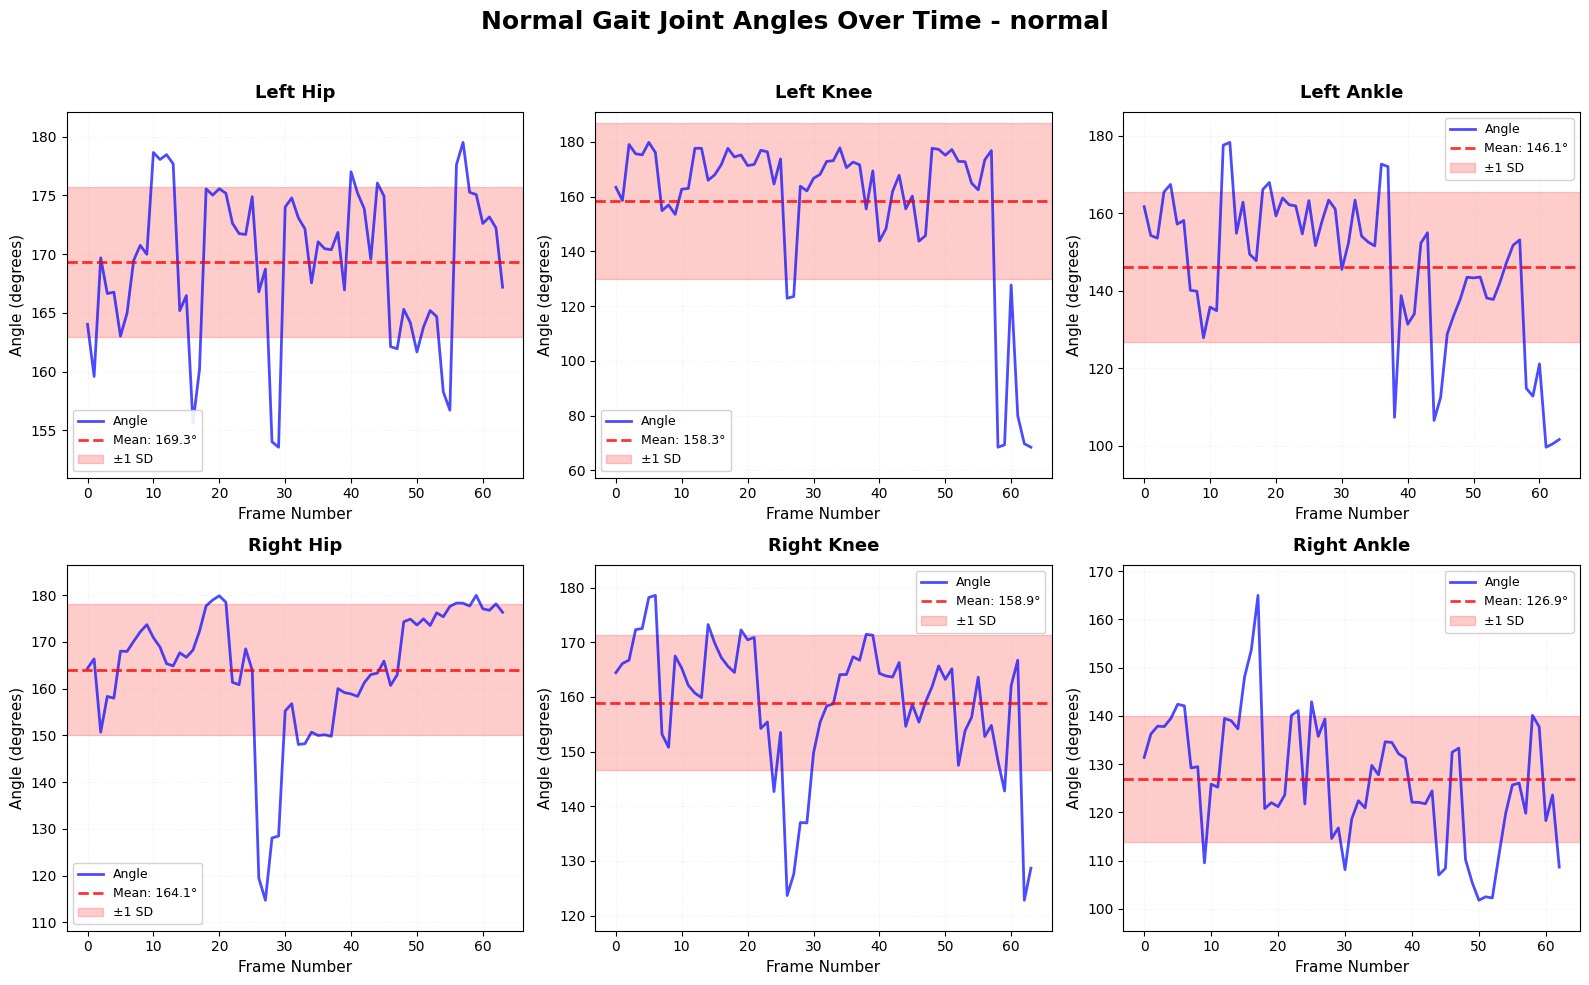


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           169.3°     6.4°   153.6°   179.5°    25.9°
left_knee          158.3°    28.4°    68.4°   179.8°   111.4°
left_ankle         146.1°    19.3°    99.6°   178.3°    78.7°
right_hip          164.1°    14.0°   114.8°   180.0°    65.2°
right_knee         158.9°    12.3°   122.8°   178.6°    55.8°
right_ankle        126.9°    13.1°   101.8°   165.0°    63.2°



In [22]:
plot_joint_angles_statistics("Normal Gait", normal_joint_angles)


Visualizing joint angles for Stroke Gait...
Number of frames with joint angles: 166


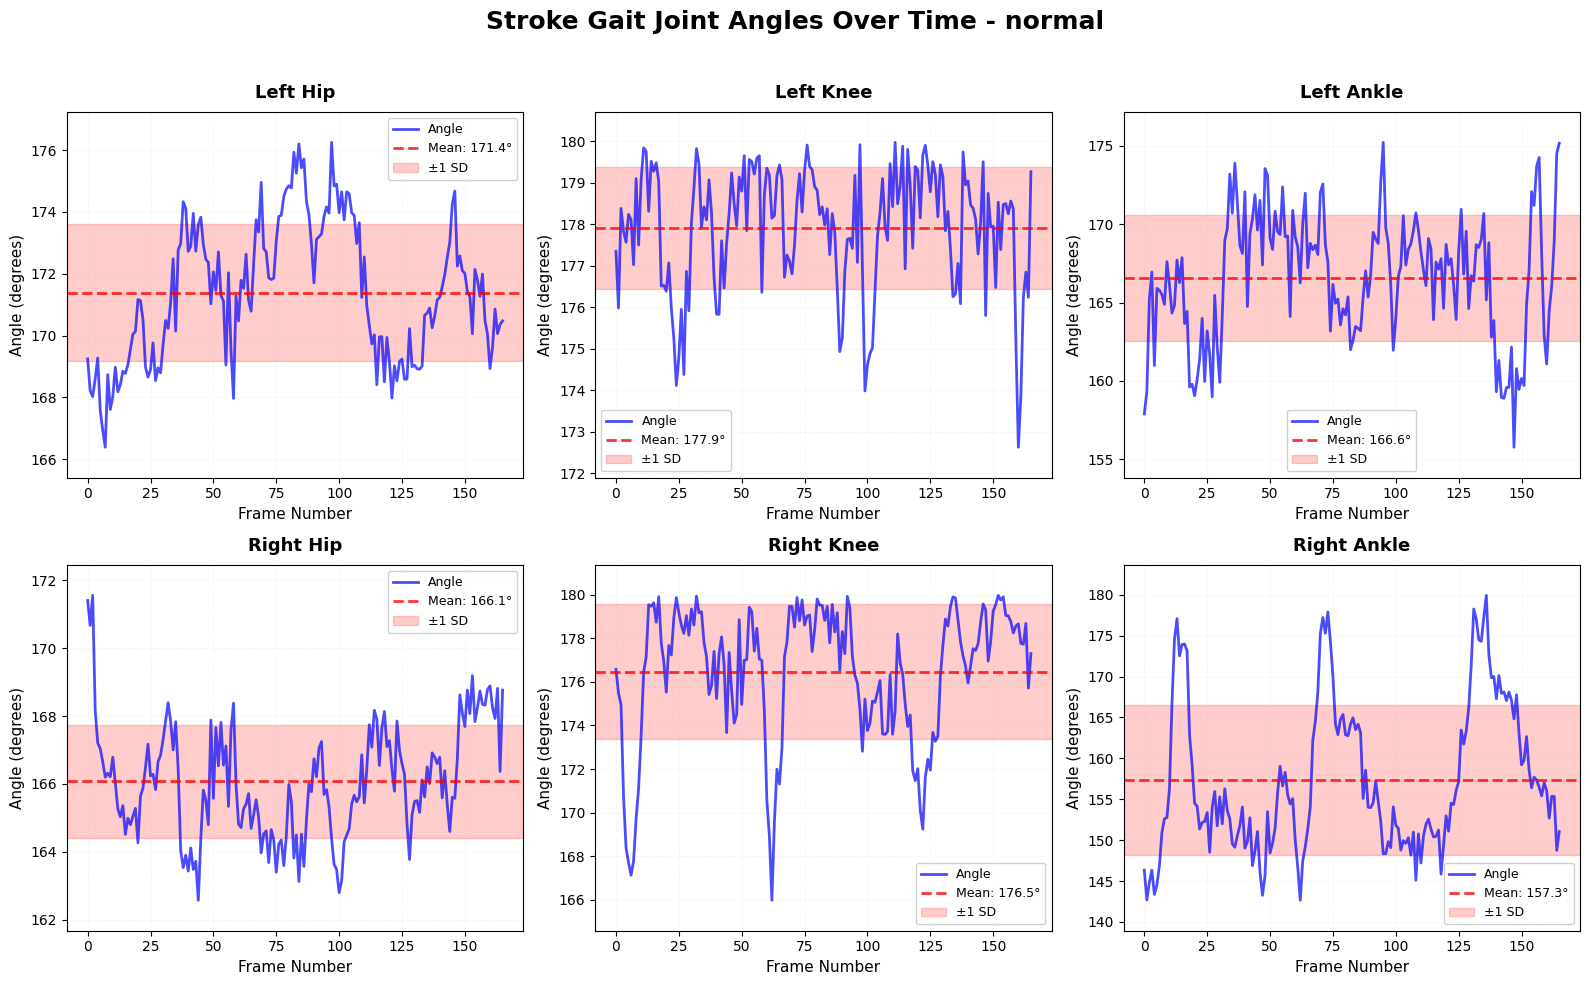


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           171.4°     2.2°   166.4°   176.3°     9.9°
left_knee          177.9°     1.5°   172.6°   180.0°     7.4°
left_ankle         166.6°     4.0°   155.8°   175.2°    19.5°
right_hip          166.1°     1.7°   162.6°   171.6°     9.0°
right_knee         176.5°     3.1°   166.0°   180.0°    14.0°
right_ankle        157.3°     9.1°   142.7°   179.9°    37.3°



In [23]:
plot_joint_angles_statistics("Stroke Gait", stroke_joint_angles)


Visualizing joint angles for Parkinsons Gait...
Number of frames with joint angles: 81


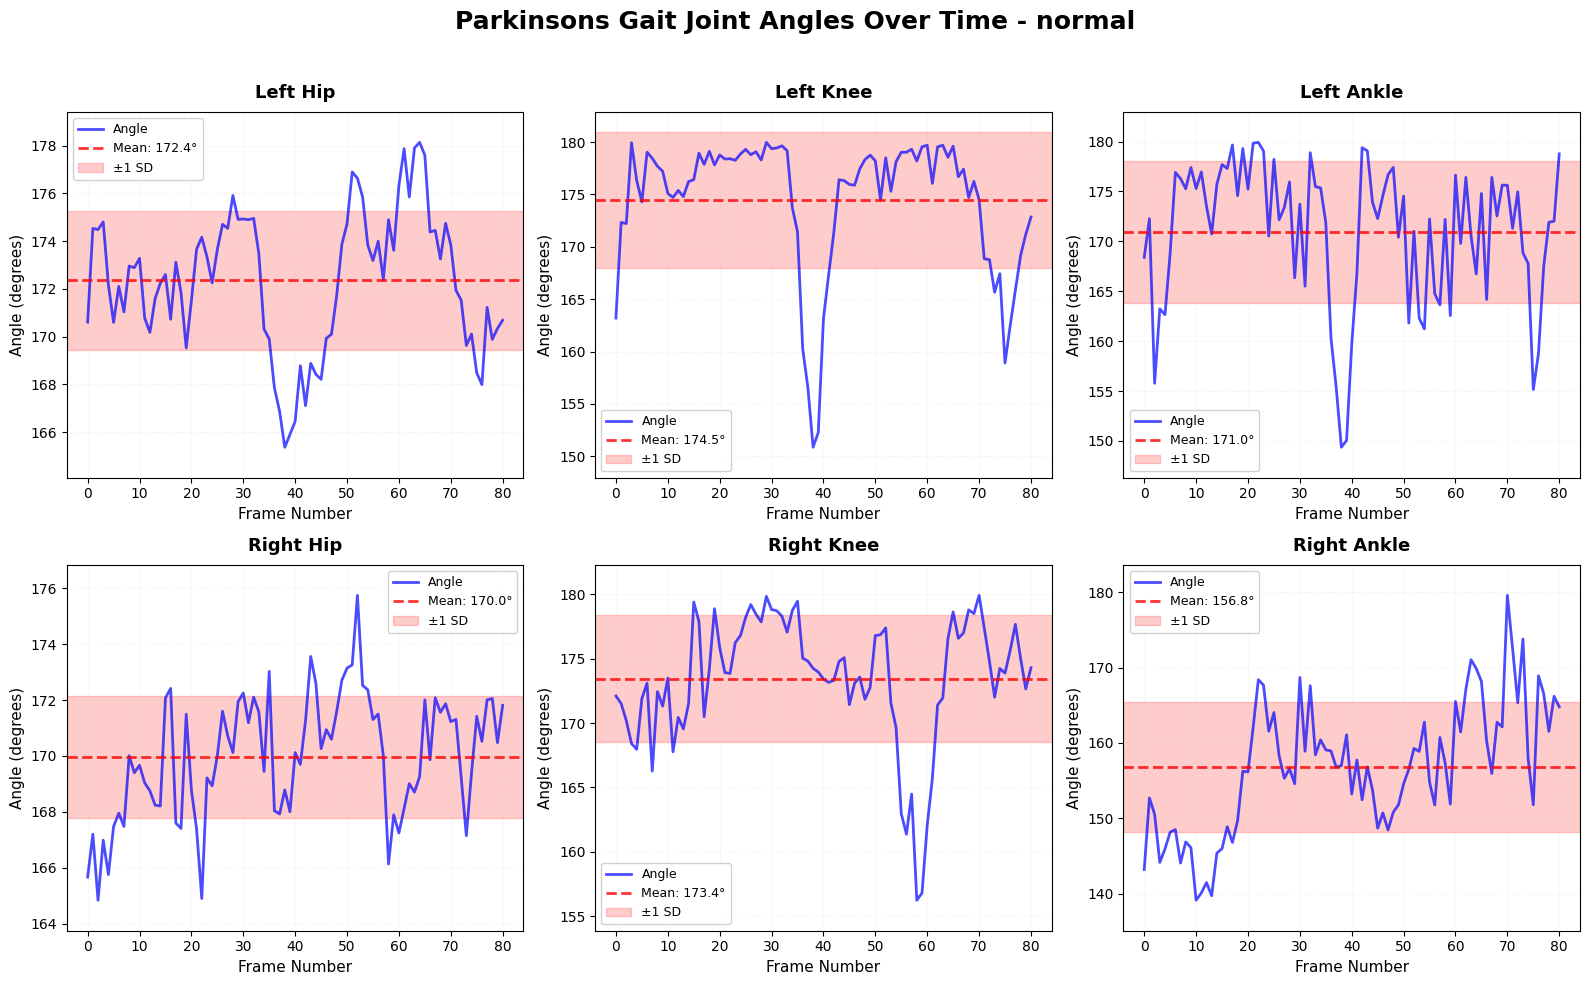


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           172.4°     2.9°   165.4°   178.1°    12.8°
left_knee          174.5°     6.5°   150.9°   180.0°    29.1°
left_ankle         171.0°     7.1°   149.4°   179.9°    30.6°
right_hip          170.0°     2.2°   164.8°   175.7°    10.9°
right_knee         173.4°     4.9°   156.3°   179.9°    23.6°
right_ankle        156.8°     8.6°   139.1°   179.6°    40.5°



In [24]:
plot_joint_angles_statistics("Parkinsons Gait", parkinsons_joint_angles)